# **Análise de dados da Retrospectiva Spotify 2025**

---
## Dessa vez eu vou fazer isso pensando na minha própria retrospectiva, não ao que o Spotify simplesmente impõe pra voce ver, faz uns cenários bonitinhos, e as pessoas aceitam de qualquer jeito, incluindo aquele negócio de qual idade voce tem pelo seu gosto musical.

---
### Vamos ao fatos do que o Spotify apresentou esse ano:
- As músicas mais ouvidas (as 5 mais ouvida)
- Artistas mais ouvidos (os 5 mais ouvidos)
- O artista mais ouvido
- Os álbuns mais ouvidos
- Criação de uma playlist das 100 músicas mias ouvidas no ano
- idade musical de acordo com o que voce escutou (kkkkk)

---
# O que realmente será apresentado:
* ### Um verdadeiro Wrapped digno, filtrando do dia 1 de janeiro de 2025 até o dia 31 de dezembro de 2025, pra ser algo mais verídico. 
* ## **Da forma mais simples:**
    1. Quantidade de minutos ouvidos no total
    2. Top 5 músicas mais ouvidas
    3. A música mais ouvida (com a quantidade de minutos)
    4. Qual dia eu mais ouvi música
    5. Top 5 músicas mais tocada em determinado dia (Quais músicas tocaram naquele dia e quantas vezes/quantos minutos)
    6. Top 5 artistas mais ouvidos
    7. Criação de um .txt com as 100 músicas mais tocadas (de acordo com a quantidade de vezes tocadas)

---
# **Depois vamos analisar isso de uma forma mais profunda**:
* ### Wrapped de Identidade Musical (Perfil Profundo)
    * Quem você é musicalmente (não só o que você ouve)
    * Se você é explorador vs. conservador
    * Se você segue tendências ou cria padrões próprios
    * Seu “DNA musical”
* ### Wrapped de Fases da Vida (linha do tempo emocional)
    * Fases intensas (muitas repetições)
    * Fases exploratórias
    * Fases silenciosas
    * Fases noturnas vs diurnas
* ### Wrapped de Horários, Rotina e Comportamento
    * Seu horário emocional (ex: madrugada triste)
    * Se você ouve mais música trabalhando, estudando ou descansando
    * Se sua semana musical é diferente do fim de semana
* ### Wrapped de Playlists (como você organiza sentimentos)
    * Quantidade de playlists
    * Tamanho médio
    * Se você cria playlists temáticas ou emocionais
    * Se você cria playlists e não escuta depois
* ### Wrapped de Repetição e Apego
    * Taxa de repetição
    * “Músicas de conforto”
    * Músicas que você escutou intensamente por pouco tempo (hiperfoco)
    * Músicas que nunca te abandonaram

---
# Importação de bibliotecas e dos dados a serem utilizados

In [2]:
import pandas as pd
import os

# Caminho com barras normais (evita o SyntaxWarning de escape "\S" no Windows)
DATA_PATH = "my_spotify_data2025_total/Spotify Account Data"

files = [
    "StreamingHistory_music_0.json",
    "StreamingHistory_music_1.json",
    "StreamingHistory_music_2.json",
    "StreamingHistory_music_3.json",
]

dfs = []

for file in files:
    file_path = os.path.join(DATA_PATH, file)
    df = pd.read_json(file_path)
    dfs.append(df)

streaming = pd.concat(dfs, ignore_index=True)

---
# Definindo a data de início (01/01/2025) até o real fim do ano (31/12/2025)

In [3]:
streaming["endTime"] = pd.to_datetime(streaming["endTime"])

inicio_2025 = pd.Timestamp("2025-01-01")
fim_2025 = pd.Timestamp("2025-12-31 23:59:59")

streaming_2025 = streaming[
    (streaming["endTime"] >= inicio_2025) &
    (streaming["endTime"] <= fim_2025)
].copy()

---
# **1. Quantidade de minutos ouvidos no total**

# Separando a quantidade de minutos de 2025

In [4]:
streaming_2025["minutesPlayed"] = streaming_2025["msPlayed"] / 60000

# Um "play" (stream) só conta a partir de 30s ouvidos — mesmo critério do Spotify.
# Isso evita que skips (faixas puladas em poucos segundos) inflem a contagem de plays.
# OBS: os minutos totais continuam somando TUDO; o filtro vale só para CONTAR plays.
LIMIAR_STREAM_MS = 30_000
streaming_2025["isStream"] = streaming_2025["msPlayed"] >= LIMIAR_STREAM_MS

In [5]:
total_minutos = streaming_2025["minutesPlayed"].sum().round(2)
total_minutos

44641.3

---
# **2. Top 5 músicas mais ouvidas (de acordo com a quantidade de minutos escutados)**

In [6]:
top_5_musicas = (
    streaming_2025
    .groupby(["trackName", "artistName"], as_index=False)
    ["minutesPlayed"].sum()
    .sort_values("minutesPlayed", ascending=False)
    .head(5)
)

# Garantir 2 casas decimais
top_5_musicas["minutesPlayed"] = top_5_musicas["minutesPlayed"].round(2)

print("🎧 TOP 5 MÚSICAS MAIS OUVIDAS EM 2025 (por minutos):\n")

for idx, row in enumerate(top_5_musicas.itertuples(index=False), start=1):
    print(
        f"{idx}. {row.trackName} — {row.artistName} "
        f"({row.minutesPlayed:.2f} minutos)"
    )

🎧 TOP 5 MÚSICAS MAIS OUVIDAS EM 2025 (por minutos):

1. Novo Tango — Realygust (1182.64 minutos)
2. Tipo Kisame 2 — MHRAP (572.85 minutos)
3. Feiticeiro Descolado — MHRAP (559.11 minutos)
4. Tipo Barou Shoei — MHRAP (551.97 minutos)
5. Major Crimes — HEALTH (550.72 minutos)


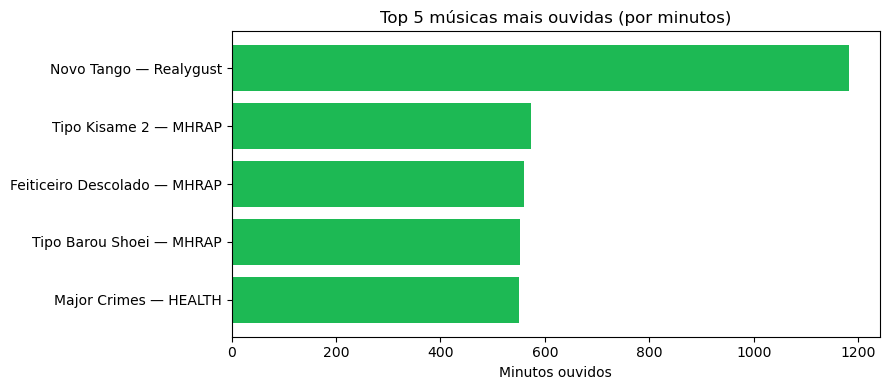

In [7]:
import matplotlib.pyplot as plt

d = top_5_musicas.iloc[::-1]
labels = [f"{t[:28]} — {a}" for t, a in zip(d["trackName"], d["artistName"])]
plt.figure(figsize=(9, 4))
plt.barh(labels, d["minutesPlayed"], color="#1DB954")
plt.xlabel("Minutos ouvidos")
plt.title("Top 5 músicas mais ouvidas (por minutos)")
plt.tight_layout()
plt.show()

---
# **3. A música mais ouvida (com a quantidade de minutos)**

In [8]:
musica_mais_ouvida = top_5_musicas.iloc[0]

print("\n🥇 MÚSICA MAIS OUVIDA DE 2025\n")

print(
    f"{musica_mais_ouvida['trackName']} - "
    f"{musica_mais_ouvida['artistName']}\n"
    f"⏱️ {musica_mais_ouvida['minutesPlayed']:.2f} minutos ouvidos"
)


🥇 MÚSICA MAIS OUVIDA DE 2025

Novo Tango - Realygust
⏱️ 1182.64 minutos ouvidos


---
# **4. Qual dia eu mais ouvi música**

In [9]:
streaming_2025["date"] = streaming_2025["endTime"].dt.date # garante a coluna de data

# minutos ouvidos por dia
minutos_por_dia = (
    streaming_2025
    .groupby("date")["minutesPlayed"]
    .sum()
    .sort_index()
)

# dia_mais_ouvido = (
#     streaming_2025
#     .groupby("date")["minutesPlayed"].sum()
#     .sort_values(ascending=False)
#     .head(1)
# )
# data_dia_top = dia_mais_ouvido.index[0]
# data_dia_top

In [10]:
dia_top = minutos_por_dia.idxmax() # identificar os dias com mais minutos

# Gráfico com o dia em que eu mais ouvi música

📅 DIA EM QUE VOCÊ MAIS OUVIU MÚSICA EM 2025:
2025-09-19


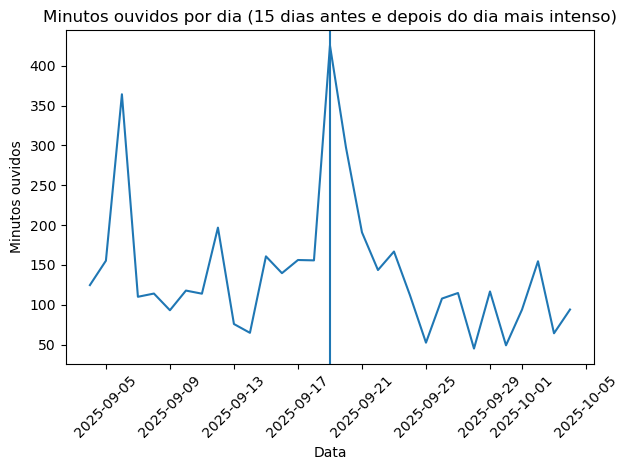

In [11]:
import matplotlib.pyplot as plt

inicio_janela = dia_top - pd.Timedelta(days=15)
fim_janela = dia_top + pd.Timedelta(days=15)

janela_dias = minutos_por_dia.loc[inicio_janela:fim_janela]

print("📅 DIA EM QUE VOCÊ MAIS OUVIU MÚSICA EM 2025:")
print(dia_top)

plt.figure()
plt.plot(janela_dias.index, janela_dias.values)
plt.axvline(dia_top)

plt.title("Minutos ouvidos por dia (15 dias antes e depois do dia mais intenso)")
plt.xlabel("Data")
plt.ylabel("Minutos ouvidos")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
# **5. Top 5 músicas mais ouvidas no dia mais intenso do ano**

_(o dia identificado automaticamente como o de mais minutos — ver acima)_

In [12]:
musicas_dia_top = (
    streaming_2025[streaming_2025["date"] == dia_top]
    .groupby(["trackName", "artistName"], as_index=False)
    .agg(
        vezes_tocada=("isStream", "sum"),   # conta só plays reais (>=30s)
        minutos=("minutesPlayed", "sum")
    )
    # 1º: mais vezes tocadas
    # 2º: mais minutos (desempate)
    .sort_values(
        by=["vezes_tocada", "minutos"],
        ascending=[False, False]
    )
    .head(5)
)

print("\n🎧 TOP 5 MÚSICAS MAIS TOCADAS NESSE DIA:\n")

for idx, row in enumerate(musicas_dia_top.itertuples(index=False), start=1):
    print(
        f"{idx}. {row.trackName} — {row.artistName} | "
        f"{row.vezes_tocada} vezes | "
        f"{row.minutos:.2f} minutos"
    )


🎧 TOP 5 MÚSICAS MAIS TOCADAS NESSE DIA:

1. aza — ANAVITÓRIA | 8 vezes | 20.77 minutos
2. como é que a gente foi chegar aqui? — ANAVITÓRIA | 8 vezes | 9.49 minutos
3. 3 am | espirais da repetição — ANAVITÓRIA | 7 vezes | 26.27 minutos
4. búzios — ANAVITÓRIA | 6 vezes | 13.36 minutos
5. o amor habita os mais inconcebíveis dos lugares — ANAVITÓRIA | 6 vezes | 7.78 minutos


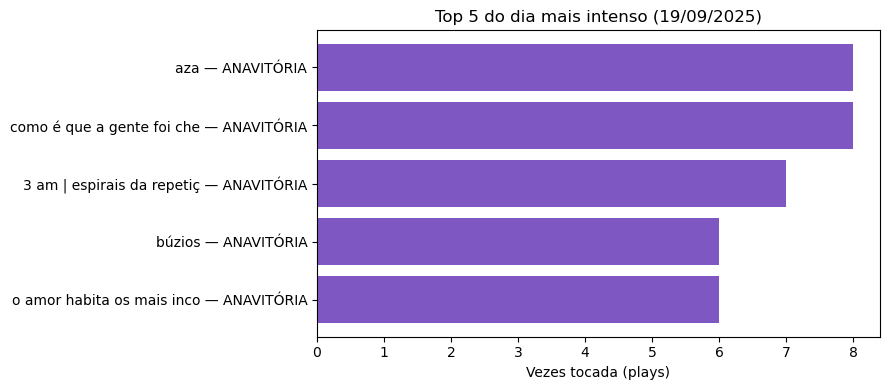

In [13]:
import matplotlib.pyplot as plt

d = musicas_dia_top.iloc[::-1]
labels = [f"{t[:26]} — {a}" for t, a in zip(d["trackName"], d["artistName"])]
plt.figure(figsize=(9, 4))
plt.barh(labels, d["vezes_tocada"], color="#7e57c2")
plt.xlabel("Vezes tocada (plays)")
plt.title(f"Top 5 do dia mais intenso ({dia_top.strftime('%d/%m/%Y')})")
plt.tight_layout()
plt.show()

---
# Comparar o dia mais ouvido com a média do ano

* ### Média diária de minutos em 2025

In [14]:
media_diaria_ano = minutos_por_dia.mean()
minutos_dia_top = minutos_por_dia.loc[dia_top]

print("📊 COMPARAÇÃO COM A MÉDIA DO ANO:\n")
print(f"Média diária em 2025: {media_diaria_ano:.2f} minutos")
print(f"Dia mais ouvido ({dia_top.strftime('%d/%m/%Y')}): {minutos_dia_top:.2f} minutos")

fator = minutos_dia_top / media_diaria_ano
print(f"\n➡️ Esse dia teve {fator:.2f}x mais minutos que a média diária do ano.")

📊 COMPARAÇÃO COM A MÉDIA DO ANO:

Média diária em 2025: 123.32 minutos
Dia mais ouvido (19/09/2025): 425.50 minutos

➡️ Esse dia teve 3.45x mais minutos que a média diária do ano.


---
# Repetição (conforto) VS Exploração (diversidade)

In [15]:
musicas_por_dia = (
    streaming_2025
    .groupby("date")["trackName"]
    .nunique()
)

media_musicas_por_dia = musicas_por_dia.mean()
musicas_dia_top = musicas_por_dia.loc[dia_top]

print("\n🎧 PADRÃO DE ESCUTA NESSE DIA:\n")
print(f"Média de músicas diferentes por dia em 2025: {media_musicas_por_dia:.2f}")
print(f"Músicas diferentes no dia mais ouvido: {musicas_dia_top}")

if musicas_dia_top < media_musicas_por_dia * 0.8:
    print("\n➡️ Padrão dominante: REPETIÇÃO (músicas de conforto)")
elif musicas_dia_top > media_musicas_por_dia * 1.2:
    print("\n➡️ Padrão dominante: EXPLORAÇÃO (muitas músicas diferentes)")
else:
    print("\n➡️ Padrão dominante: EQUILÍBRIO entre conforto e exploração")



🎧 PADRÃO DE ESCUTA NESSE DIA:

Média de músicas diferentes por dia em 2025: 70.96
Músicas diferentes no dia mais ouvido: 117

➡️ Padrão dominante: EXPLORAÇÃO (muitas músicas diferentes)


# Horário dominante desse dia

In [16]:
streaming_2025["hour"] = streaming_2025["endTime"].dt.hour # criar coluna de hora

In [17]:
horas_dia_top = (
    streaming_2025[streaming_2025["date"] == dia_top]
    .groupby("hour")["minutesPlayed"]
    .sum()
)

hora_dominante = horas_dia_top.idxmax()

print("\n🕒 HORÁRIO DOMINANTE NESSE DIA:\n")
print(f"Hora com mais música: {hora_dominante}:00")

if 0 <= hora_dominante < 6:
    periodo = "MADRUGADA"
elif 6 <= hora_dominante < 12:
    periodo = "MANHÃ"
elif 12 <= hora_dominante < 18:
    periodo = "TARDE"
else:
    periodo = "NOITE"

print(f"\nPeríodo dominante: {periodo}")


🕒 HORÁRIO DOMINANTE NESSE DIA:

Hora com mais música: 20:00

Período dominante: NOITE


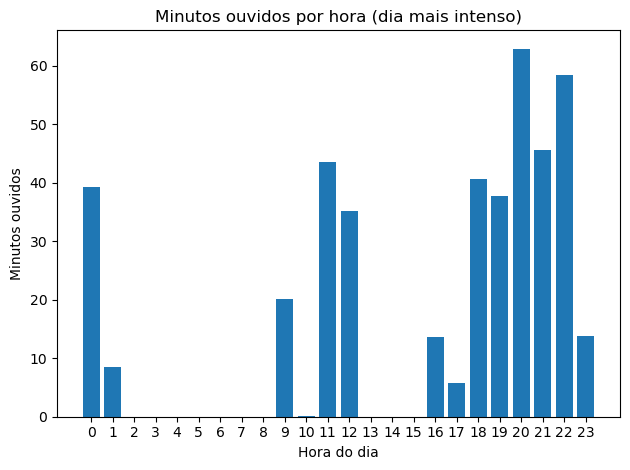

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(horas_dia_top.index, horas_dia_top.values)

plt.title("Minutos ouvidos por hora (dia mais intenso)")
plt.xlabel("Hora do dia")
plt.ylabel("Minutos ouvidos")

plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

---
# **6. Top 5 artistas mais ouvidos no ano**

In [19]:
top_5_artistas = (
    streaming_2025
    .groupby("artistName", as_index=False)
    ["minutesPlayed"].sum()
    .sort_values("minutesPlayed", ascending=False)
    .head(5)
)

top_5_artistas["minutesPlayed"] = top_5_artistas["minutesPlayed"].round(2)

print("🎤 TOP 5 ARTISTAS MAIS OUVIDOS EM 2025 (por minutos):\n")

for idx, row in enumerate(top_5_artistas.itertuples(index=False), start=1):
    print(
        f"{idx}. {row.artistName} "
        f"({row.minutesPlayed:.2f} minutos)"
    )

🎤 TOP 5 ARTISTAS MAIS OUVIDOS EM 2025 (por minutos):

1. Realygust (4444.80 minutos)
2. MHRAP (4131.15 minutos)
3. VMZ (2543.32 minutos)
4. Florence Lil Flowers (2018.06 minutos)
5. ANAVITÓRIA (1806.84 minutos)


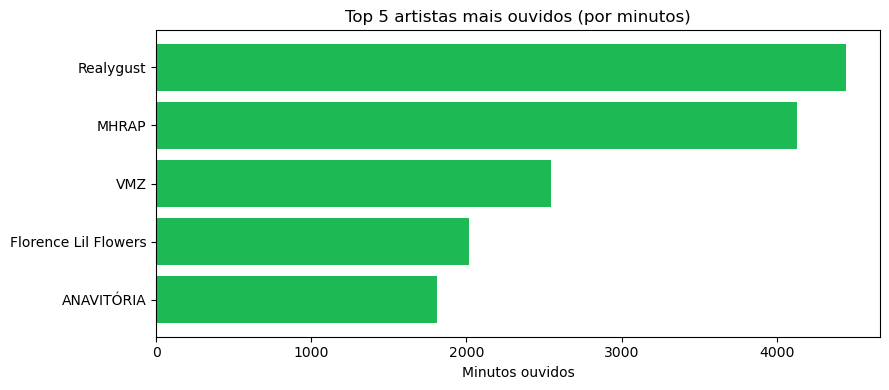

In [20]:
import matplotlib.pyplot as plt

d = top_5_artistas.iloc[::-1]
plt.figure(figsize=(9, 4))
plt.barh(d["artistName"], d["minutesPlayed"], color="#1DB954")
plt.xlabel("Minutos ouvidos")
plt.title("Top 5 artistas mais ouvidos (por minutos)")
plt.tight_layout()
plt.show()

---
# **7. Criação de um .txt com as 100 músicas mais tocadas (de acordo com a quantidade de vezes tocadas/minutos tocados)**

In [21]:
top_100_musicas = (
    streaming_2025
    .groupby(["trackName", "artistName"], as_index=False)
    .agg(
        minutos_escutados=("minutesPlayed", "sum"),
        vezes_tocada=("isStream", "sum")   # conta só plays reais (>=30s)
    )
    .sort_values(
        ["minutos_escutados", "vezes_tocada"],
        ascending=[False, False]
    )
    .head(100)
    .reset_index(drop=True)   # índice 0..99 vira o ranking real
)

# Arredondar minutos
top_100_musicas["minutos_escutados"] = top_100_musicas["minutos_escutados"].round(2)

# Pra mostrar todas as 100 músicas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(top_100_musicas)

,trackName,artistName,minutos_escutados,vezes_tocada
0,Novo Tango,Realygust,1182.64,475
1,Tipo Kisame 2,MHRAP,572.85,188
2,Feiticeiro Descolado,MHRAP,559.11,142
3,Tipo Barou Shoei,MHRAP,551.97,148
4,Major Crimes,HEALTH,550.72,151
5,Compromisso,Realygust,462.27,166
6,Tipo Madara 2,MHRAP,392.00,160
7,Paixão Pelo Dinheiro,Realygust,348.36,162
8,Presente,Realygust,327.77,140
9,Tava Na Mal,Realygust,305.69,133


In [22]:
output_path = "top_100_musicas_2025.txt"

with open(output_path, "w", encoding="utf-8") as f:
    for rank, row in enumerate(top_100_musicas.itertuples(index=False), start=1):
        f.write(
            f"{rank:03d}. {row.trackName} - {row.artistName} | "
            f"{row.minutos_escutados} min | "
            f"{row.vezes_tocada} plays\n"
        )

print(f"✅ Arquivo gerado: {output_path} ({len(top_100_musicas)} músicas)")

✅ Arquivo gerado: top_100_musicas_2025.txt (100 músicas)


---
# **Agora vamos para uma análise mais aprofundada**

* ### 1. Wrapped de Identidade Musical (Perfil Profundo)
    * Quem você é musicalmente (não só o que você ouve)
    * Se você é explorador vs. conservador
    * Se você segue tendências ou cria padrões próprios
    * Seu “DNA musical”
* ### 2. Wrapped de Fases da Vida (linha do tempo emocional)
    * Fases intensas (muitas repetições)
    * Fases exploratórias
    * Fases silenciosas
    * Fases noturnas vs diurnas
* ### 3. Wrapped de Horários, Rotina e Comportamento
    * Seu horário emocional (ex: madrugada triste)
    * Se você ouve mais música trabalhando, estudando ou descansando
    * Se sua semana musical é diferente do fim de semana
* ### 4. Wrapped de Playlists (como você organiza sentimentos)
    * Quantidade de playlists
    * Tamanho médio
    * Se você cria playlists temáticas ou emocionais
    * Se você cria playlists e não escuta depois
* ### 5. Wrapped de Repetição e Apego
    * Taxa de repetição
    * “Músicas de conforto”
    * Músicas que você escutou intensamente por pouco tempo (hiperfoco)
    * Músicas que nunca te abandonaram

---
# **1. Wrapped de Identidade Musical (Perfil Profundo)**

## **1️⃣ Explorador vs. Conservador (Score)**

### % de músicas ouvidas apenas 1 vez

In [23]:
plays_por_musica = (
    streaming_2025[streaming_2025["isStream"]]   # só plays reais (>=30s)
    .groupby(["trackName", "artistName"])
    .size()
    .reset_index(name="plays")
)

percent_unicas = (
    plays_por_musica[plays_por_musica["plays"] == 1].shape[0]
    / plays_por_musica.shape[0]
)

# plays_por_musica 

### Concentração no Top 20

In [24]:
tempo_total = streaming_2025["minutesPlayed"].sum()

top_20_tempo = (
    streaming_2025
    .groupby(["trackName", "artistName"])
    ["minutesPlayed"].sum()
    .sort_values(ascending=False)
    .head(20)
    .sum()
)

concentracao_top20 = top_20_tempo / tempo_total
concentracao_top20

0.17597291270356358

### Score Explorador

Interpretação:

0.0–0.3 → Conservador

0.3–0.6 → Equilibrado

0.6–1.0 → Explorador

In [25]:
score_explorador = (
    0.6 * percent_unicas +
    0.4 * (1 - concentracao_top20)
)
score_explorador.round(2)

0.67

## **2️⃣ Centralização do Gosto**

### Quantos artistas fazem 50% do tempo

In [26]:
tempo_por_artista = (
    streaming_2025
    .groupby("artistName")["minutesPlayed"]
    .sum()
    .sort_values(ascending=False)
)

acumulado = tempo_por_artista.cumsum() / tempo_por_artista.sum()
artistas_50 = acumulado[acumulado <= 0.5].count()

### Score de centralização (normalizado)
* Próximo de 1 → gosto concentrado

* Próximo de 0 → gosto disperso

In [27]:
score_centralizacao = 1 - (artistas_50 / tempo_por_artista.shape[0])
score_centralizacao = max(0, min(score_centralizacao, 1))

score_centralizacao

0.9956575682382134

# **3️⃣ Repetição Emocional**

# **🧠 Interpretação do score**
## **🔹 0.00 – 0.30 → Baixa repetição emocional**

* Você raramente volta à mesma música

* Consumo mais racional ou exploratório

* Música como descoberta, não refúgio

## 🧬 Perfil típico:

* ### **“Explorador sonoro / curador”**

# **🔹 0.30 – 0.60 → Repetição emocional moderada**

* Você cria zonas de conforto

* Algumas músicas funcionam como âncoras

* Equilíbrio entre novidade e familiaridade

## 🧬 Perfil típico:

* ### **“Afetivo equilibrado”**

# **🔹 0.60 – 0.85 → Alta repetição emocional**

* Forte vínculo emocional com certas músicas

* Reescuta como regulação emocional

* Trilhas sonoras pessoais para fases da vida

## 🧬 Perfil típico:

* ### **“Imersivo emocional”**

# **🔹 0.85 – 1.00 → Repetição muito alta**

* Poucas músicas dominam o ano

* Loop emocional claro

* Música como companhia constante

## 🧬 Perfil típico:

* ### **“Nostálgico / Refúgio emocional”**

### Média de plays por música

* Quantas vezes, em média, você volta para a mesma música.
* Não mede popularidade
* Não mede tempo
* Mede apego e retorno emocional

In [28]:
media_plays = plays_por_musica["plays"].mean()
media_plays.round(2)

5.22

### Normalização simples

* media_plays = 10 → score máximo (1.0)
* Valores acima disso saturam (não distorcem o índice)
* É uma escolha intencional para evitar outliers dominarem o perfil.

In [29]:
score_repeticao = min(media_plays / 10, 1)

print(f'{score_repeticao.round(2)}')

0.52


# **4️⃣ Intensidade de Escuta**

In [30]:
minutos_por_play = (
    streaming_2025["minutesPlayed"].sum()
    / streaming_2025["isStream"].sum()   # divide pelos plays reais, não por todas as linhas
)

score_intensidade = min(minutos_por_play / 5, 1)

# **5️⃣ DNA Musical (vetor final)**

In [31]:
dna_musical = {
    "exploracao": round(float(score_explorador), 2),
    "centralizacao": round(float(score_centralizacao), 2),
    "repeticao": round(float(score_repeticao), 2),
    "intensidade": round(float(score_intensidade), 2)
}

dna_musical

{'exploracao': 0.67,
 'centralizacao': 1.0,
 'repeticao': 0.52,
 'intensidade': 0.49}

In [32]:
def interpretar_metrica(nome, valor):
    if nome == "exploracao":
        if valor >= 0.6:
            return (
                "Exploração alta",
                "Você busca novidade com frequência e não se contenta em repetir fórmulas.",
                "Explorador consciente"
            )
        elif valor >= 0.3:
            return (
                "Exploração moderada",
                "Você equilibra descoberta e familiaridade.",
                "Explorador equilibrado"
            )
        else:
            return (
                "Exploração baixa",
                "Você prefere territórios musicais conhecidos.",
                "Conservador afetivo"
            )

    if nome == "centralizacao":
        if valor >= 0.7:
            return (
                "Centralização muito alta",
                "Poucos artistas concentram grande parte da sua escuta.",
                "Identidade musical sólida"
            )
        elif valor >= 0.4:
            return (
                "Centralização moderada",
                "Seu gosto se distribui entre vários núcleos.",
                "Identidade flexível"
            )
        else:
            return (
                "Centralização baixa",
                "Seu gosto é amplamente distribuído.",
                "Perfil difuso"
            )

    if nome == "repeticao":
        if valor >= 0.6:
            return (
                "Repetição emocional alta",
                "Você cria laços fortes e revisita músicas como refúgio.",
                "Imersivo emocional"
            )
        elif valor >= 0.4:
            return (
                "Repetição emocional moderada",
                "Você repete quando faz sentido, não por hábito.",
                "Afetivo racional"
            )
        else:
            return (
                "Repetição emocional baixa",
                "Você prefere seguir em frente a permanecer.",
                "Explorador desapegado"
            )

    if nome == "intensidade":
        if valor >= 0.6:
            return (
                "Alta intensidade",
                "Você se aprofunda longamente nas músicas.",
                "Ouvinte imersivo"
            )
        elif valor >= 0.4:
            return (
                "Intensidade moderada",
                "Sua escuta alterna entre foco e fluxo.",
                "Ouvinte equilibrado"
            )
        else:
            return (
                "Baixa intensidade",
                "A música acompanha seus movimentos.",
                "Ouvinte de percurso"
            )


In [33]:
# Lê direto do dna_musical calculado (sem valores digitados à mão)
for chave, valor in dna_musical.items():
    titulo, texto, perfil = interpretar_metrica(chave, valor)
    print(f"🎧 {titulo}")
    print(f"{texto}")
    print(f"Perfil típico: {perfil}\n")

🎧 Exploração alta
Você busca novidade com frequência e não se contenta em repetir fórmulas.
Perfil típico: Explorador consciente

🎧 Centralização muito alta
Poucos artistas concentram grande parte da sua escuta.
Perfil típico: Identidade musical sólida

🎧 Repetição emocional moderada
Você repete quando faz sentido, não por hábito.
Perfil típico: Afetivo racional

🎧 Intensidade moderada
Sua escuta alterna entre foco e fluxo.
Perfil típico: Ouvinte equilibrado



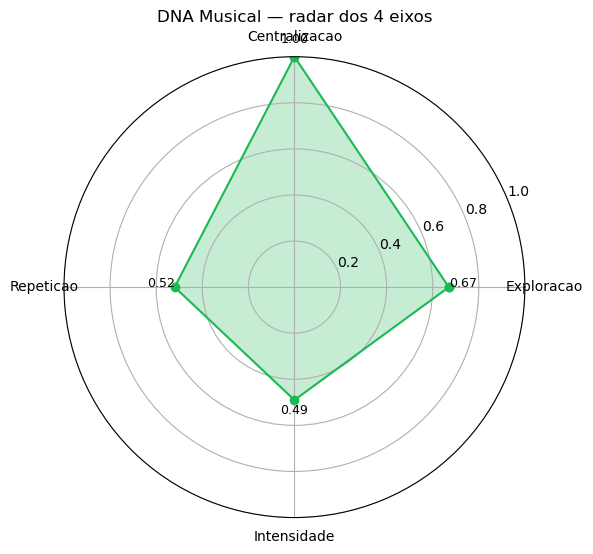

In [67]:
import matplotlib.pyplot as plt
import numpy as np

rotulos = list(dna_musical.keys())
valores = list(dna_musical.values())
angulos = np.linspace(0, 2 * np.pi, len(rotulos), endpoint=False).tolist()
valores_c = valores + valores[:1]
angulos_c = angulos + angulos[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angulos_c, valores_c, marker="o", color="#1DB954")
ax.fill(angulos_c, valores_c, alpha=0.25, color="#1DB954")
ax.set_xticks(angulos)
ax.set_xticklabels([r.capitalize() for r in rotulos])
ax.set_ylim(0, 1)
ax.set_title("DNA Musical — radar dos 4 eixos")
for ang, val in zip(angulos, valores):
    ax.text(ang, val + 0.06, f"{val:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

---

---
# 🧬 Seu DNA Musical — Leitura Profunda



## 🌍 Exploração — **0.67** _(Alta)_

**Você é claramente explorador.**  
Você não fica preso a um único território sonoro: testa artistas, fases, estilos e climas com frequência.

> *Você não escuta música só para repetir o que já conhece — você usa a música como descoberta.  
Existe curiosidade ativa no seu ouvir.*

**Perfil típico:**  
🎧 **Explorador consciente** — não é aleatório, você explora com intenção.

---

## 🔒 Centralização — **1.00** _(Muito alta)_

Aqui está o **traço mais forte do seu DNA**.  
Apesar de explorar bastante, o seu tempo de escuta se concentra fortemente em poucos pilares.

> *Você pode até circular por muitos sons,  
mas sempre volta para alguns poucos lugares que realmente importam.*

**Isso indica:**
- artistas “casa”
- fases musicais bem definidas
- identidade sonora clara

**Perfil típico:**  
🏠 **Explorador com base fixa** — o mundo é grande, mas você sabe onde é seu lar musical.

---

## 🔁 Repetição emocional — **0.52** _(Moderada)_

Você não vive em loop emocional,  
mas também não descarta o vínculo afetivo.

> *Você não se apega por apego.  
Quando repete uma música, é porque ela ainda tem algo a dizer —  
e quando não tem mais, você segue.*

**Perfil típico:**  
🧠 **Afetivo racional** — emoção presente, mas não dominante.

---

## ⏳ Intensidade — **0.49** _(Moderada)_

Sua escuta alterna entre foco e fluxo.  
Você nem sempre se afunda na mesma faixa por longos períodos, mas também não vive só de passagem.

> *Às vezes você mergulha numa música; às vezes ela só acompanha o movimento.  
Há equilíbrio entre imersão e percurso.*

**Isso pode indicar:**
- momentos de foco intenso intercalados com escuta funcional
- playlists que misturam mergulho e rotina

**Perfil típico:**  
🌊 **Ouvinte equilibrado** — entre a imersão e a trilha sonora da vida em movimento.

---

## 🧠 Síntese honesta do seu perfil

Você é alguém que **explora bastante**,  
mas se **ancora fortemente em poucos artistas ou estilos**.

Sua relação com a música **não é obsessiva nem dispersa** —  
ela é **estruturada, consciente e identitária**.

> *A música te acompanha, mas não te prende.  
Ela organiza o caminho.*

**Isso não é um perfil comum.**  
A maioria das pessoas é:
- ou exploradora e dispersa
- ou repetitiva e fechada

Você é **explorador com identidade forte** — e isso é raro.

---
# **2. Wrapped de Fases da Vida (linha do tempo emocional)**
* Fases intensas (muitas repetições)
* Fases exploratórias
* Fases silenciosas
* Fases noturnas vs diurnas

In [35]:
# Linha do tempo: agrega a escuta mês a mês ao longo de 2025
streaming_2025["mes"] = streaming_2025["endTime"].dt.to_period("M")

perfil_mensal = (
    streaming_2025
    .groupby("mes")
    .agg(
        minutos=("minutesPlayed", "sum"),
        plays=("isStream", "sum"),
        musicas_unicas=("trackName", "nunique"),
    )
)
# Intensidade do mês = quão repetitivo ele foi (plays por música diferente)
perfil_mensal["intensidade"] = (perfil_mensal["plays"] / perfil_mensal["musicas_unicas"]).round(2)
perfil_mensal["minutos"] = perfil_mensal["minutos"].round(0)

# Rótulos de mês em PT pra leitura
meses_pt = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
            7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"}
perfil_mensal["rotulo"] = [meses_pt[p.month] for p in perfil_mensal.index]

perfil_mensal

,minutos,plays,musicas_unicas,intensidade,rotulo
mes,,,,,
2025-01,3358.0,1303,900,1.45,Jan
2025-02,4135.0,1617,1019,1.59,Fev
2025-03,2798.0,1131,820,1.38,Mar
2025-04,3028.0,1188,908,1.31,Abr
2025-05,3515.0,1624,2057,0.79,Mai
2025-06,3858.0,1585,1582,1.00,Jun
2025-07,4855.0,2041,1748,1.17,Jul
2025-08,4183.0,1649,1538,1.07,Ago
2025-09,4453.0,1815,1227,1.48,Set


---
## 📈 Linha do tempo — volume, diversidade e intensidade

Três curvas que contam o ano: **quanto** você ouviu, **quão variado** foi e **quão repetitivo** foi cada mês.

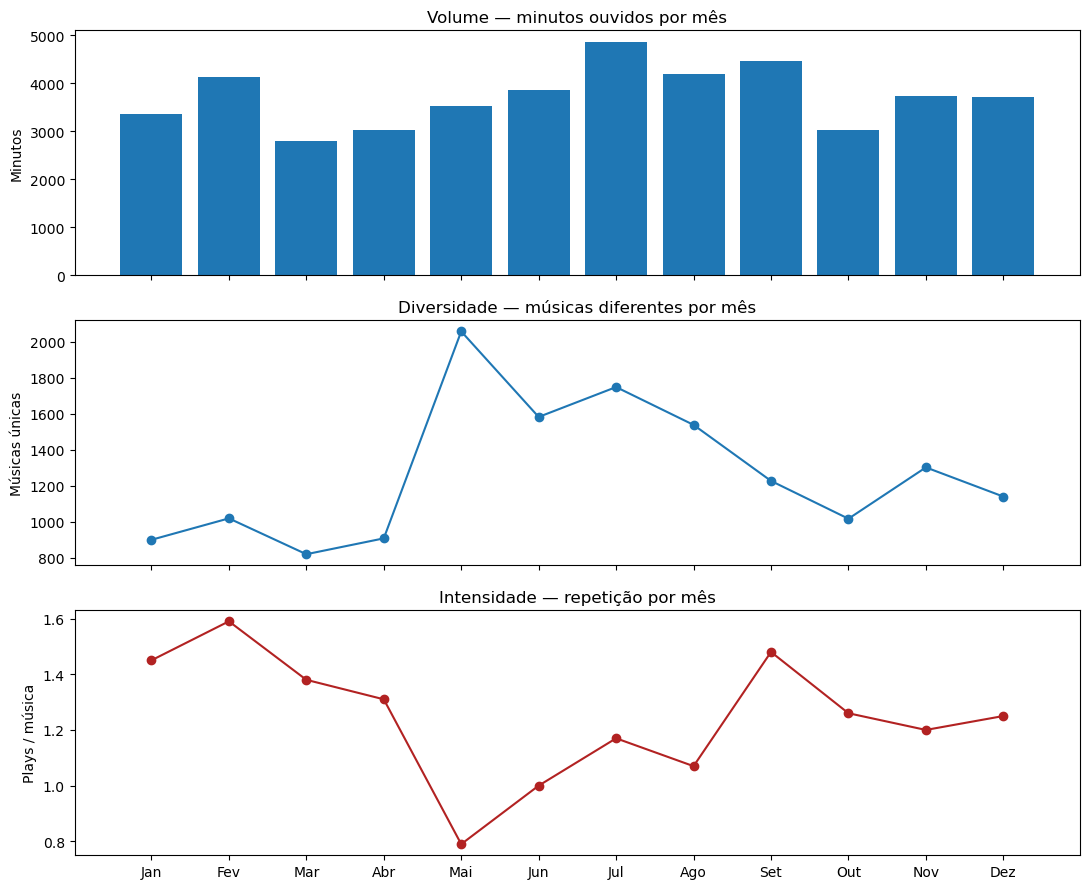

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
x = range(len(perfil_mensal))

axes[0].bar(x, perfil_mensal["minutos"])
axes[0].set_ylabel("Minutos")
axes[0].set_title("Volume — minutos ouvidos por mês")

axes[1].plot(x, perfil_mensal["musicas_unicas"], marker="o")
axes[1].set_ylabel("Músicas únicas")
axes[1].set_title("Diversidade — músicas diferentes por mês")

axes[2].plot(x, perfil_mensal["intensidade"], marker="o", color="firebrick")
axes[2].set_ylabel("Plays / música")
axes[2].set_title("Intensidade — repetição por mês")

axes[2].set_xticks(list(x))
axes[2].set_xticklabels(perfil_mensal["rotulo"])
plt.tight_layout()
plt.show()

---
## 📅 As fases do ano

Cada mês é classificado em relação à **sua própria média de 2025**: meses **silenciosos** (pouca escuta), **intensos** (muita repetição), **exploratórios** (muita música nova) ou **equilibrados**.

In [37]:
# Classifica cada mês comparando com a média do ano
media_min = perfil_mensal["minutos"].mean()
media_div = perfil_mensal["musicas_unicas"].mean()
media_int = perfil_mensal["intensidade"].mean()

def classificar_mes(row):
    if row["minutos"] < media_min * 0.7:
        return "🔇 Silenciosa"
    if row["intensidade"] > media_int * 1.15:
        return "🔁 Intensa (repetição)"
    if row["musicas_unicas"] > media_div * 1.15:
        return "🧭 Exploratória"
    return "⚖️ Equilibrada"

perfil_mensal["fase"] = perfil_mensal.apply(classificar_mes, axis=1)

print("📅 AS FASES DO SEU ANO\n")
for p, row in perfil_mensal.iterrows():
    print(f"{row['rotulo']}: {row['fase']:22s} "
          f"| {int(row['minutos'])} min, {int(row['musicas_unicas'])} músicas, {row['intensidade']} plays/música")

📅 AS FASES DO SEU ANO

Jan: 🔁 Intensa (repetição)  | 3358 min, 900 músicas, 1.45 plays/música
Fev: 🔁 Intensa (repetição)  | 4135 min, 1019 músicas, 1.59 plays/música
Mar: ⚖️ Equilibrada         | 2798 min, 820 músicas, 1.38 plays/música
Abr: ⚖️ Equilibrada         | 3028 min, 908 músicas, 1.31 plays/música
Mai: 🧭 Exploratória         | 3515 min, 2057 músicas, 0.79 plays/música
Jun: 🧭 Exploratória         | 3858 min, 1582 músicas, 1.0 plays/música
Jul: 🧭 Exploratória         | 4855 min, 1748 músicas, 1.17 plays/música
Ago: 🧭 Exploratória         | 4183 min, 1538 músicas, 1.07 plays/música
Set: 🔁 Intensa (repetição)  | 4453 min, 1227 músicas, 1.48 plays/música
Out: ⚖️ Equilibrada         | 3024 min, 1017 músicas, 1.26 plays/música
Nov: ⚖️ Equilibrada         | 3723 min, 1302 músicas, 1.2 plays/música
Dez: ⚖️ Equilibrada         | 3713 min, 1140 músicas, 1.25 plays/música


---
## 🎤 O artista-tema de cada mês

A "cara sonora" de cada mês de 2025 — o artista que mais ocupou seus minutos.

In [38]:
# Artista que mais definiu cada mês (por minutos ouvidos)
print("🎤 O ARTISTA-TEMA DE CADA MÊS\n")
for p in perfil_mensal.index:
    sub = streaming_2025[streaming_2025["mes"] == p]
    artista_mes = sub.groupby("artistName")["minutesPlayed"].sum().idxmax()
    print(f"{meses_pt[p.month]}: {artista_mes}")

🎤 O ARTISTA-TEMA DE CADA MÊS

Jan: MHRAP
Fev: VMZ
Mar: MHRAP
Abr: MHRAP
Mai: Mc Gabzin
Jun: Realygust
Jul: Realygust
Ago: Realygust
Set: Realygust
Out: Realygust
Nov: MHRAP
Dez: Realygust


---
## 🧠 Síntese — o arco do seu ano

In [39]:
print("🧠 SÍNTESE — FASES DA VIDA\n")

mes_pico = perfil_mensal["minutos"].idxmax()
mes_quieto = perfil_mensal["minutos"].idxmin()
mes_explora = perfil_mensal["musicas_unicas"].idxmax()
mes_intenso = perfil_mensal["intensidade"].idxmax()

print(f"📈 Mês mais musical: {meses_pt[mes_pico.month]} ({int(perfil_mensal.loc[mes_pico, 'minutos'])} min).")
print(f"🔇 Mês mais quieto: {meses_pt[mes_quieto.month]} ({int(perfil_mensal.loc[mes_quieto, 'minutos'])} min).")
print(f"🧭 Mês mais explorador: {meses_pt[mes_explora.month]} ({int(perfil_mensal.loc[mes_explora, 'musicas_unicas'])} músicas diferentes).")
print(f"🔁 Mês mais obsessivo: {meses_pt[mes_intenso.month]} ({perfil_mensal.loc[mes_intenso, 'intensidade']} plays/música).")

n_fases = perfil_mensal["fase"].value_counts()
print("\nSeu ano teve de tudo: " + ", ".join(f"{v}x {k}" for k, v in n_fases.items()))

🧠 SÍNTESE — FASES DA VIDA

📈 Mês mais musical: Jul (4855 min).
🔇 Mês mais quieto: Mar (2798 min).
🧭 Mês mais explorador: Mai (2057 músicas diferentes).
🔁 Mês mais obsessivo: Fev (1.59 plays/música).

Seu ano teve de tudo: 5x ⚖️ Equilibrada, 4x 🧭 Exploratória, 3x 🔁 Intensa (repetição)


---
# **3. Wrapped de Horários, Rotina e Comportamento**

Quando você ouve música diz muito sobre sua rotina. Aqui olhamos o **relógio** e o **calendário** da sua escuta — sem inventar humor, só o comportamento real.

In [40]:
# Preparo: dia da semana, flag de fim de semana e período do dia
dias_semana_ordem = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dias_semana_pt = {
    "Monday": "Seg", "Tuesday": "Ter", "Wednesday": "Qua", "Thursday": "Qui",
    "Friday": "Sex", "Saturday": "Sáb", "Sunday": "Dom"
}

streaming_2025["dia_semana"] = streaming_2025["endTime"].dt.day_name()
streaming_2025["fim_de_semana"] = streaming_2025["dia_semana"].isin(["Saturday", "Sunday"])

def classificar_periodo(h):
    if 0 <= h < 6:
        return "Madrugada"
    if 6 <= h < 12:
        return "Manhã"
    if 12 <= h < 18:
        return "Tarde"
    return "Noite"

streaming_2025["periodo"] = streaming_2025["hour"].apply(classificar_periodo)

---
## 🔥 Mapa de calor: hora × dia da semana

Cada célula é quanto você ouviu naquele cruzamento de dia e hora. Quanto mais claro/quente, mais minutos.

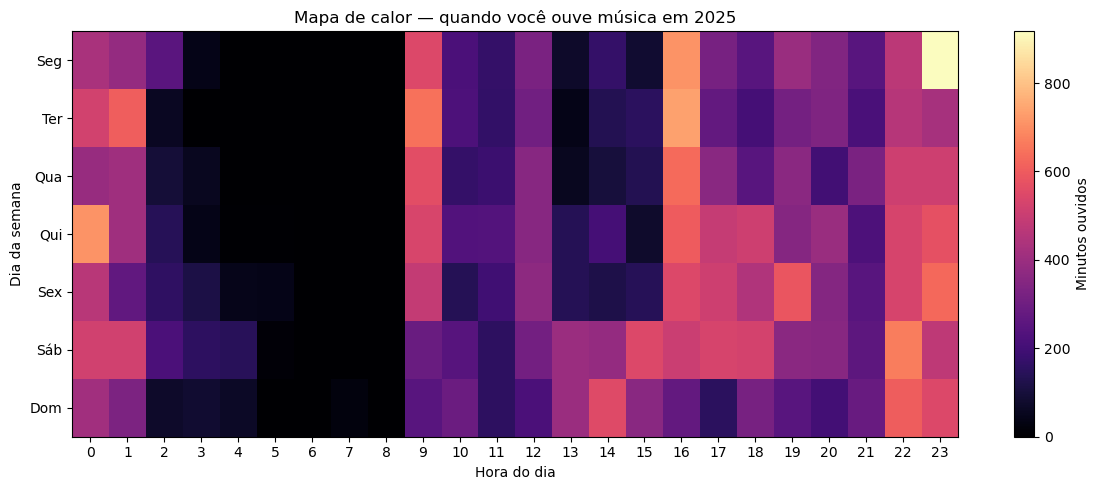

In [41]:
import matplotlib.pyplot as plt

# Minutos por (dia da semana x hora)
mapa = (
    streaming_2025
    .groupby(["dia_semana", "hour"])["minutesPlayed"].sum()
    .unstack(fill_value=0)
    .reindex(dias_semana_ordem)
    .reindex(columns=range(24), fill_value=0)
)

plt.figure(figsize=(12, 5))
plt.imshow(mapa.values, aspect="auto", cmap="magma")
plt.colorbar(label="Minutos ouvidos")
plt.yticks(range(7), [dias_semana_pt[d] for d in dias_semana_ordem])
plt.xticks(range(24))
plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana")
plt.title("Mapa de calor — quando você ouve música em 2025")
plt.tight_layout()
plt.show()

---
## 📆 Semana vs. fim de semana

Comparando a **média por dia** (justo, já que são 5 dias úteis contra 2 de fim de semana).

In [42]:
# Média de minutos POR DIA (justo: compara dia útil vs dia de fds, não soma total)
min_por_dia = streaming_2025.groupby("date")["minutesPlayed"].sum()
fds_por_dia = streaming_2025.groupby("date")["fim_de_semana"].first()

media_semana = min_por_dia[~fds_por_dia].mean()
media_fds = min_por_dia[fds_por_dia].mean()

print("📆 SEMANA vs FIM DE SEMANA (média de minutos por dia)\n")
print(f"Dia útil (seg–sex):      {media_semana:.0f} min/dia")
print(f"Fim de semana (sáb–dom): {media_fds:.0f} min/dia")

dif = (media_fds / media_semana - 1) * 100
print(f"\n➡️ No fim de semana você ouve {abs(dif):.0f}% {'a MAIS' if dif > 0 else 'a MENOS'} por dia.")

📆 SEMANA vs FIM DE SEMANA (média de minutos por dia)

Dia útil (seg–sex):      120 min/dia
Fim de semana (sáb–dom): 131 min/dia

➡️ No fim de semana você ouve 8% a MAIS por dia.


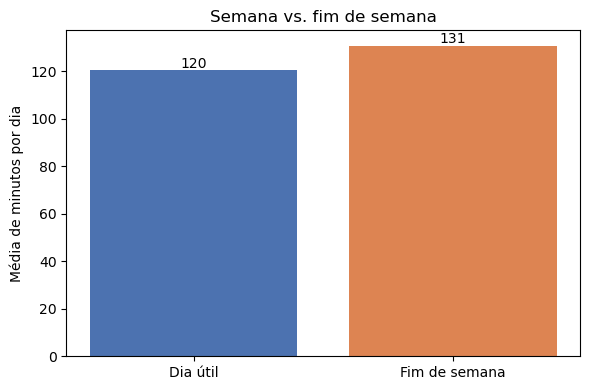

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
barras = plt.bar(["Dia útil", "Fim de semana"], [media_semana, media_fds],
                 color=["#4c72b0", "#dd8452"])
plt.ylabel("Média de minutos por dia")
plt.title("Semana vs. fim de semana")
for b, v in zip(barras, [media_semana, media_fds]):
    plt.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}", ha="center")
plt.tight_layout()
plt.show()

---
## 🌗 Períodos do dia

Quanto da sua música rola em cada parte do dia — e qual artista define cada período.

In [44]:
# Distribuição de minutos por período do dia + artista-cara de cada período
ordem_periodos = ["Madrugada", "Manhã", "Tarde", "Noite"]
min_periodo = (
    streaming_2025.groupby("periodo")["minutesPlayed"].sum()
    .reindex(ordem_periodos)
)
pct = (min_periodo / min_periodo.sum() * 100).round(1)

print("🕒 SUA ESCUTA AO LONGO DO DIA\n")
for p in ordem_periodos:
    artista_top = (
        streaming_2025[streaming_2025["periodo"] == p]
        .groupby("artistName")["minutesPlayed"].sum().idxmax()
    )
    print(f"{p:10s}: {pct[p]:5.1f}% dos minutos  |  artista-cara: {artista_top}")

🕒 SUA ESCUTA AO LONGO DO DIA

Madrugada :  18.4% dos minutos  |  artista-cara: Realygust
Manhã     :  13.7% dos minutos  |  artista-cara: Realygust
Tarde     :  29.8% dos minutos  |  artista-cara: Realygust
Noite     :  38.0% dos minutos  |  artista-cara: MHRAP


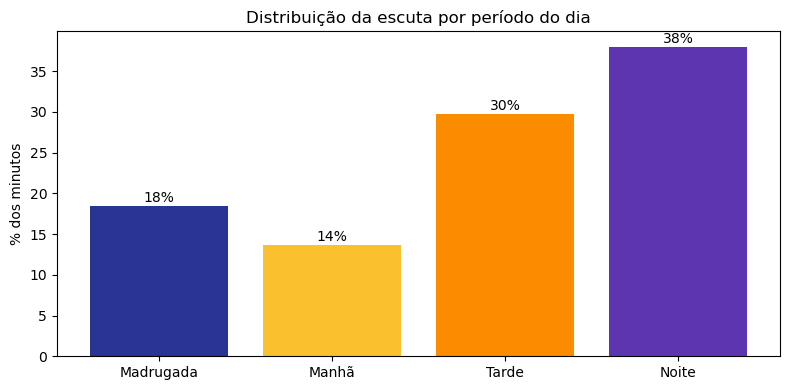

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
barras = plt.bar(pct.index, pct.values, color=["#283593", "#fbc02d", "#fb8c00", "#5e35b1"])
plt.ylabel("% dos minutos")
plt.title("Distribuição da escuta por período do dia")
for b, v in zip(barras, pct.values):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.0f}%", ha="center")
plt.tight_layout()
plt.show()

---
## 🧠 Síntese — seu relógio musical

In [46]:
print("🧠 SÍNTESE — HORÁRIOS E ROTINA\n")

# Horário de pico
min_por_hora = streaming_2025.groupby("hour")["minutesPlayed"].sum()
hora_pico = int(min_por_hora.idxmax())

# Coruja vs diurno: fração da escuta na madrugada (0h–5h)
frac_madrugada = (
    streaming_2025[streaming_2025["hour"].between(0, 5)]["minutesPlayed"].sum()
    / streaming_2025["minutesPlayed"].sum()
)

periodo_dominante = min_periodo.idxmax()

print(f"⏰ Seu horário de pico é às {hora_pico}h.")
print(f"🌗 Período dominante do ano: {periodo_dominante} ({pct[periodo_dominante]:.0f}% dos minutos).")
if frac_madrugada >= 0.15:
    print(f"🦉 Você tem veia coruja: {frac_madrugada:.0%} da sua música rola na madrugada.")
else:
    print(f"☀️ Você é mais diurno: só {frac_madrugada:.0%} da escuta na madrugada.")
if media_fds > media_semana:
    print("🎉 Sua música cresce no fim de semana — escuta mais ligada a lazer.")
else:
    print("💼 Você ouve mais nos dias úteis — música acompanha a rotina/trabalho.")

🧠 SÍNTESE — HORÁRIOS E ROTINA

⏰ Seu horário de pico é às 23h.
🌗 Período dominante do ano: Noite (38% dos minutos).
🦉 Você tem veia coruja: 18% da sua música rola na madrugada.
🎉 Sua música cresce no fim de semana — escuta mais ligada a lazer.


---
# **4. Wrapped de Playlists**

Como você **organiza sentimentos** em playlists: quantas tem, de que tamanho, como nomeia — e quais você criou e **nunca mais ouviu**.

> Fonte: `Playlist1.json` (suas playlists), cruzado com o streaming de 2025.

In [47]:
import json

with open(os.path.join(DATA_PATH, "Playlist1.json"), encoding="utf-8") as f:
    playlists_raw = json.load(f)["playlists"]

df_playlists = pd.DataFrame([
    {
        "nome": p["name"],
        "n_tracks": len(p["items"]),
        "modificada": p["lastModifiedDate"],
        "tem_descricao": bool(p.get("description")),
    }
    for p in playlists_raw
])

print("📂 SUAS PLAYLISTS EM NÚMEROS\n")
print(f"Total de playlists: {len(df_playlists)}")
print(f"Total de faixas somadas: {df_playlists['n_tracks'].sum()}")
print(f"Tamanho médio: {df_playlists['n_tracks'].mean():.0f} faixas")
print(f"Tamanho mediano: {df_playlists['n_tracks'].median():.0f} faixas")
print(f"Com descrição escrita: {df_playlists['tem_descricao'].sum()} ({df_playlists['tem_descricao'].mean():.0%})")

📂 SUAS PLAYLISTS EM NÚMEROS

Total de playlists: 65
Total de faixas somadas: 7154
Tamanho médio: 110 faixas
Tamanho mediano: 68 faixas
Com descrição escrita: 26 (40%)


---
## 📐 Tamanhos — da maior à menor

🏆 Maior: 'Trap/Rap' (793 faixas)
🐭 Menor: 'Partilhar' (1 faixas)


C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\3753321136.py:13: UserWarning: Glyph 127748 (\N{SUNRISE OVER MOUNTAINS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\3753321136.py:13: UserWarning: Glyph 127796 (\N{PALM TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\3753321136.py:13: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\3753321136.py:13: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\3753321136.py:13: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Ferramentas\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127748 (\N{SUNRISE OVER MOUNTAINS}) missing from font(s) De

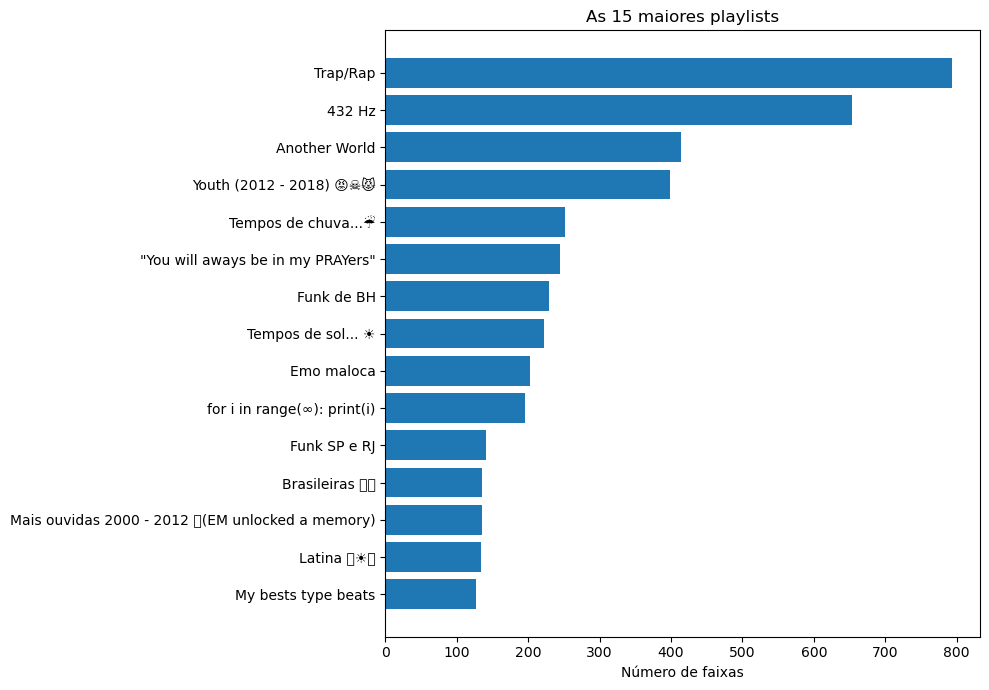

In [48]:
import matplotlib.pyplot as plt

maior = df_playlists.loc[df_playlists["n_tracks"].idxmax()]
menor = df_playlists.loc[df_playlists["n_tracks"].idxmin()]
print(f"🏆 Maior: '{maior['nome']}' ({maior['n_tracks']} faixas)")
print(f"🐭 Menor: '{menor['nome']}' ({menor['n_tracks']} faixas)")

top15 = df_playlists.sort_values("n_tracks", ascending=True).tail(15)
plt.figure(figsize=(10, 7))
plt.barh(top15["nome"], top15["n_tracks"])
plt.xlabel("Número de faixas")
plt.title("As 15 maiores playlists")
plt.tight_layout()
plt.show()

---
## 🗂️ Como você organiza

Classificação aproximada **pelo nome** da playlist: cronológicas (com ano), por artista, de clima/vibe, ou temáticas diversas.

In [49]:
import re

artistas_conhecidos = set(streaming_2025["artistName"].str.lower().unique())

def categorizar_playlist(nome):
    n = nome.lower()
    # Cronológica / retrospectiva (tem ano, "mais tocadas", "perdidos")
    if re.search(r"(19|20)\d{2}", n) or "mais tocadas" in n or "perdidos" in n:
        return "📅 Cronológica"
    # Por artista (nome bate com artista ouvido, ou é "tipo X" = type beat)
    if n.startswith("tipo ") or n.strip() in artistas_conhecidos:
        return "🎤 Por artista"
    # Clima / vibe / emocional
    if re.search(r"tempos|vibe|brisa|chuva|\bsol\b|nublad|frio|lembra|home|prayer|inspira|brisa", n):
        return "🌦️ Clima / vibe"
    return "🎲 Outras / temáticas"

df_playlists["categoria"] = df_playlists["nome"].apply(categorizar_playlist)

print("🗂️ COMO VOCÊ ORGANIZA SUAS PLAYLISTS (heurística pelo nome)\n")
for cat, q in df_playlists["categoria"].value_counts().items():
    print(f"{cat}: {q} playlists")

🗂️ COMO VOCÊ ORGANIZA SUAS PLAYLISTS (heurística pelo nome)

🎲 Outras / temáticas: 34 playlists
🌦️ Clima / vibe: 12 playlists
📅 Cronológica: 10 playlists
🎤 Por artista: 9 playlists


C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\30158430.py:8: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\30158430.py:8: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\30158430.py:8: UserWarning: Glyph 127782 (\N{WHITE SUN BEHIND CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hian\AppData\Local\Temp\ipykernel_2948\30158430.py:8: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Ferramentas\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Ferramentas\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu 

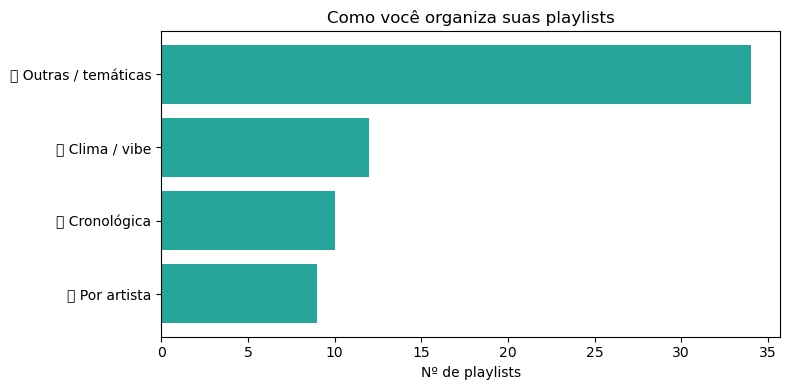

In [50]:
import matplotlib.pyplot as plt

vc = df_playlists["categoria"].value_counts()
plt.figure(figsize=(8, 4))
plt.barh(vc.index[::-1], vc.values[::-1], color="#26a69a")
plt.xlabel("Nº de playlists")
plt.title("Como você organiza suas playlists")
plt.tight_layout()
plt.show()

---
## 🧠 Síntese — como você organiza sentimentos em playlists

In [51]:
print("🧠 SÍNTESE — PLAYLISTS")
print()
cat_top = df_playlists["categoria"].value_counts().idxmax()
print(f"🗂️ Você organiza principalmente por: {cat_top}.")
print(f"📐 Suas playlists variam de {df_playlists['n_tracks'].min()} a {df_playlists['n_tracks'].max()} faixas "
      f"(mediana {df_playlists['n_tracks'].median():.0f}).")
frac_desc = df_playlists["tem_descricao"].mean()
print(f"✍️ Você escreve descrição em {frac_desc:.0%} delas — "
      + ("gosta de dar contexto às playlists." if frac_desc >= 0.4 else "raramente explica."))

🧠 SÍNTESE — PLAYLISTS

🗂️ Você organiza principalmente por: 🎲 Outras / temáticas.
📐 Suas playlists variam de 1 a 793 faixas (mediana 68).
✍️ Você escreve descrição em 40% delas — gosta de dar contexto às playlists.


---
# **5. Wrapped de Repetição e Apego**

Como você se relaciona com as músicas ao longo do tempo: o que vira **conforto**, o que vira **hiperfoco** passageiro e o que **nunca te abandona**.

> Aqui um "play" só conta a partir de 30s ouvidos (`isStream`), pra não confundir apego com faixas puladas.

In [52]:
# Base de apego: um registro por música com plays reais, espalhamento e longevidade
streams = streaming_2025[streaming_2025["isStream"]].copy()
streams["mes"] = streams["endTime"].dt.to_period("M")

perfil_musica = (
    streams
    .groupby(["trackName", "artistName"], as_index=False)
    .agg(
        plays=("isStream", "sum"),
        minutos=("minutesPlayed", "sum"),
        dias_distintos=("date", "nunique"),
        meses_distintos=("mes", "nunique"),
        primeiro=("date", "min"),
        ultimo=("date", "max"),
    )
)
perfil_musica["span_dias"] = (
    pd.to_datetime(perfil_musica["ultimo"]) - pd.to_datetime(perfil_musica["primeiro"])
).dt.days + 1
perfil_musica["plays_por_dia_ativo"] = (
    perfil_musica["plays"] / perfil_musica["dias_distintos"]
).round(2)
perfil_musica["minutos"] = perfil_musica["minutos"].round(2)

# Taxa de repetição: que fração dos seus plays foi "voltar" a uma música já ouvida
total_plays = int(perfil_musica["plays"].sum())
musicas_unicas = perfil_musica.shape[0]
taxa_repeticao = 1 - musicas_unicas / total_plays

print("🔁 REPETIÇÃO GERAL EM 2025\n")
print(f"Plays reais (>=30s): {total_plays}")
print(f"Músicas diferentes: {musicas_unicas}")
print(f"Média de plays por música: {total_plays / musicas_unicas:.2f}")
print(f"Taxa de repetição: {taxa_repeticao:.1%} dos seus plays foram re-escutas")

🔁 REPETIÇÃO GERAL EM 2025

Plays reais (>=30s): 18217
Músicas diferentes: 3492
Média de plays por música: 5.22
Taxa de repetição: 80.8% dos seus plays foram re-escutas


---
## 🛋️ Músicas de conforto

Você volta nelas em **muitos dias diferentes** ao longo do ano — não pela intensidade de um momento, mas pela presença constante.

In [53]:
# Conforto = músicas que você reencontra em MUITOS dias diferentes ao longo do ano
conforto = (
    perfil_musica[perfil_musica["plays"] >= 10]
    .sort_values(["dias_distintos", "plays"], ascending=[False, False])
    .head(10)
)

print("🛋️ MÚSICAS DE CONFORTO (companhia recorrente ao longo do ano)\n")
for i, r in enumerate(conforto.itertuples(index=False), 1):
    print(
        f"{i:2d}. {r.trackName} — {r.artistName} | "
        f"{r.dias_distintos} dias diferentes | {r.plays} plays | "
        f"ativa por {r.span_dias} dias"
    )

🛋️ MÚSICAS DE CONFORTO (companhia recorrente ao longo do ano)

 1. Novo Tango — Realygust | 131 dias diferentes | 475 plays | ativa por 186 dias
 2. Tipo Madara 2 — MHRAP | 103 dias diferentes | 160 plays | ativa por 360 dias
 3. Tipo Kisame 2 — MHRAP | 89 dias diferentes | 188 plays | ativa por 312 dias
 4. Miami — Realygust | 87 dias diferentes | 156 plays | ativa por 187 dias
 5. Feiticeiro Descolado — MHRAP | 84 dias diferentes | 142 plays | ativa por 356 dias
 6. Paixão Pelo Dinheiro — Realygust | 80 dias diferentes | 162 plays | ativa por 187 dias
 7. Dar Bom — Realygust | 73 dias diferentes | 117 plays | ativa por 185 dias
 8. Compromisso — Realygust | 72 dias diferentes | 166 plays | ativa por 175 dias
 9. Eu Posso Ser Seu Psicólogo — Realygust | 67 dias diferentes | 94 plays | ativa por 363 dias
10. Presente — Realygust | 64 dias diferentes | 140 plays | ativa por 187 dias


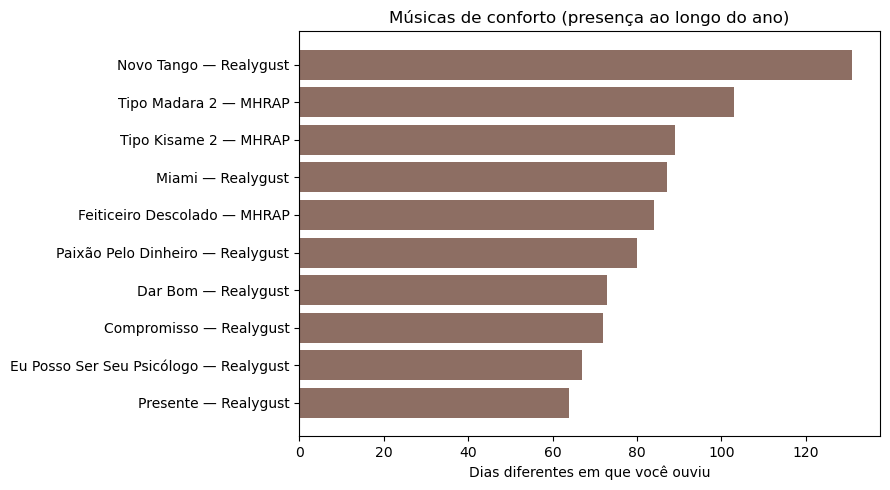

In [54]:
import matplotlib.pyplot as plt

d = conforto.iloc[::-1]
labels = [f"{t[:26]} — {a}" for t, a in zip(d["trackName"], d["artistName"])]
plt.figure(figsize=(9, 5))
plt.barh(labels, d["dias_distintos"], color="#8d6e63")
plt.xlabel("Dias diferentes em que você ouviu")
plt.title("Músicas de conforto (presença ao longo do ano)")
plt.tight_layout()
plt.show()

---
## 🔥 Hiperfoco — obsessões curtas

Músicas que você tocou bastante numa **janela curta de tempo** (poucas semanas) e depois deixou de lado. Seu perfil não é de repetir a mesma faixa dezenas de vezes no mesmo dia — é mais de **mergulhar num som por um período e seguir em frente**.

In [55]:
# Hiperfoco = plays concentrados numa JANELA curta de tempo (obsessão de poucas semanas)
perfil_musica["intensidade_janela"] = (
    perfil_musica["plays"] / perfil_musica["span_dias"]
).round(2)

hiperfoco = (
    perfil_musica[(perfil_musica["plays"] >= 20) & (perfil_musica["span_dias"] <= 30)]
    .sort_values(["intensidade_janela", "plays"], ascending=[False, False])
    .head(10)
)

print("🔥 HIPERFOCO (obsessões intensas e curtas)\n")
for i, r in enumerate(hiperfoco.itertuples(index=False), 1):
    print(
        f"{i:2d}. {r.trackName} — {r.artistName} | "
        f"{r.plays} plays numa janela de ~{r.span_dias} dias | "
        f"{r.intensidade_janela} plays/dia na fase"
    )

🔥 HIPERFOCO (obsessões intensas e curtas)

 1. NUNCA VIU NINGUÉM — LWIS MC | 32 plays numa janela de ~10 dias | 3.2 plays/dia na fase
 2. DISCUSSÃO — LWIS MC | 21 plays numa janela de ~10 dias | 2.1 plays/dia na fase
 3. POLE — LWIS MC | 21 plays numa janela de ~10 dias | 2.1 plays/dia na fase
 4. Self Love (Spider-Man: Across the Spider-Verse) (Metro Boomin & Coi Leray) — Metro Boomin | 26 plays numa janela de ~23 dias | 1.13 plays/dia na fase


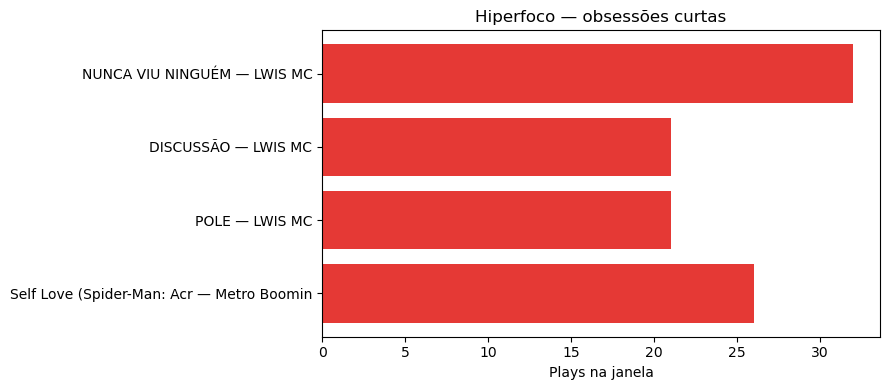

In [56]:
import matplotlib.pyplot as plt

if len(hiperfoco):
    d = hiperfoco.iloc[::-1]
    labels = [f"{t[:26]} — {a}" for t, a in zip(d["trackName"], d["artistName"])]
    plt.figure(figsize=(9, 4))
    plt.barh(labels, d["plays"], color="#e53935")
    plt.xlabel("Plays na janela")
    plt.title("Hiperfoco — obsessões curtas")
    plt.tight_layout()
    plt.show()

---
## 🧷 Músicas que nunca te abandonaram

Aparecem em **muitos meses diferentes**, espalhadas do começo ao fim do ano — a trilha sonora de fundo de 2025.

In [57]:
# Trilha do ano = músicas que apareceram em vários meses, do começo ao fim de 2025
nunca_abandonaram = (
    perfil_musica[perfil_musica["meses_distintos"] >= 6]
    .sort_values(["meses_distintos", "span_dias", "plays"], ascending=[False, False, False])
    .head(10)
)

print("🧷 MÚSICAS QUE NUNCA TE ABANDONARAM (presentes o ano todo)\n")
for i, r in enumerate(nunca_abandonaram.itertuples(index=False), 1):
    print(
        f"{i:2d}. {r.trackName} — {r.artistName} | "
        f"{r.meses_distintos} meses diferentes | "
        f"de {r.primeiro} a {r.ultimo} | {r.plays} plays"
    )

🧷 MÚSICAS QUE NUNCA TE ABANDONARAM (presentes o ano todo)

 1. Eu Posso Ser Seu Psicólogo — Realygust | 12 meses diferentes | de 2025-01-02 a 2025-12-30 | 94 plays
 2. momento — Luccas Carlos | 12 meses diferentes | de 2025-01-02 a 2025-12-30 | 64 plays
 3. Quase Lá — Realygust | 12 meses diferentes | de 2025-01-02 a 2025-12-29 | 47 plays
 4. Feiticeiro Descolado — MHRAP | 12 meses diferentes | de 2025-01-03 a 2025-12-24 | 142 plays
 5. MOVIBE — Alee | 12 meses diferentes | de 2025-01-08 a 2025-12-26 | 53 plays
 6. Columbia — Quevedo | 12 meses diferentes | de 2025-01-09 a 2025-12-26 | 59 plays
 7. São Conrado — Mc Gabzin | 12 meses diferentes | de 2025-01-01 a 2025-12-13 | 56 plays
 8. Espetáculo estranho — ANAVITÓRIA | 12 meses diferentes | de 2025-01-06 a 2025-12-13 | 43 plays
 9. PELAS ÁREAS — Fontes | 11 meses diferentes | de 2025-01-02 a 2025-12-30 | 91 plays
10. Tipo Madara 2 — MHRAP | 11 meses diferentes | de 2025-01-01 a 2025-12-26 | 160 plays


---
## 📈 Mapa do apego

Cada ponto é uma música. **Direita** = você voltou nela em muitos dias (conforto). **Topo-esquerda** = muitos plays em poucos dias (hiperfoco).

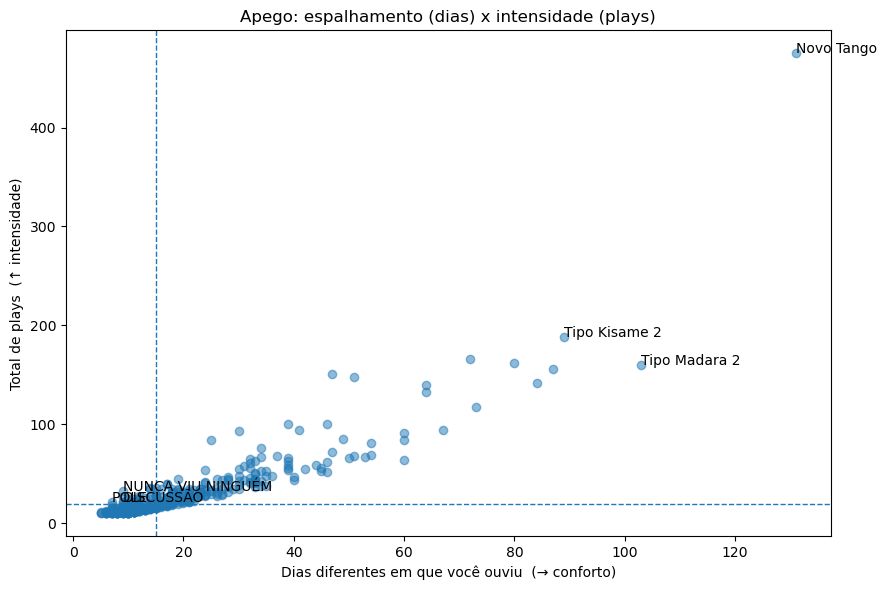

In [58]:
import matplotlib.pyplot as plt

base = perfil_musica[perfil_musica["plays"] >= 10]

plt.figure(figsize=(9, 6))
plt.scatter(base["dias_distintos"], base["plays"], alpha=0.5)

# Linhas de referência (medianas) pra separar conforto x hiperfoco
med_dias = base["dias_distintos"].median()
med_plays = base["plays"].median()
plt.axvline(med_dias, linestyle="--", linewidth=1)
plt.axhline(med_plays, linestyle="--", linewidth=1)

# Destacar as campeãs de cada perfil
for r in conforto.head(3).itertuples(index=False):
    plt.annotate(r.trackName, (r.dias_distintos, r.plays))
for r in hiperfoco.head(3).itertuples(index=False):
    plt.annotate(r.trackName, (r.dias_distintos, r.plays))

plt.title("Apego: espalhamento (dias) x intensidade (plays)")
plt.xlabel("Dias diferentes em que você ouviu  (→ conforto)")
plt.ylabel("Total de plays  (↑ intensidade)")
plt.tight_layout()
plt.show()

---
## 🧠 Síntese — o que a repetição diz sobre você

In [59]:
print("🧠 SÍNTESE — REPETIÇÃO E APEGO\n")

if taxa_repeticao >= 0.6:
    perfil_rep = "Você vive muito de re-escuta: a maior parte dos seus plays é voltar ao já conhecido."
elif taxa_repeticao >= 0.4:
    perfil_rep = "Você equilibra re-escuta e descoberta — repete bastante, mas sem viver em loop."
else:
    perfil_rep = "Você é mais de seguir em frente: poucas re-escutas, muito conteúdo novo."

musica_conforto = conforto.iloc[0]
musica_hiperfoco = hiperfoco.iloc[0] if len(hiperfoco) else None
musica_trilha = nunca_abandonaram.iloc[0] if len(nunca_abandonaram) else None

print(perfil_rep)
print(f"\n🛋️ Sua maior companhia: '{musica_conforto['trackName']}' "
      f"({musica_conforto['dias_distintos']} dias diferentes).")
if musica_hiperfoco is not None:
    print(f"🔥 Sua maior fase-relâmpago: '{musica_hiperfoco['trackName']}' "
          f"({int(musica_hiperfoco['plays'])} plays numa janela de ~{int(musica_hiperfoco['span_dias'])} dias).")
if musica_trilha is not None:
    print(f"🧷 A trilha do seu ano: '{musica_trilha['trackName']}' "
          f"({int(musica_trilha['meses_distintos'])} meses diferentes).")

# Observação honesta sobre o padrão: este perfil é de "grazer", não de "binger"
if perfil_musica["intensidade_janela"].max() < 5:
    print("\n📝 Você raramente martela a mesma faixa num único dia — sua intensidade vem de "
          "voltar às músicas por semanas/meses, não de repeti-las em rajada.")

🧠 SÍNTESE — REPETIÇÃO E APEGO

Você vive muito de re-escuta: a maior parte dos seus plays é voltar ao já conhecido.

🛋️ Sua maior companhia: 'Novo Tango' (131 dias diferentes).
🔥 Sua maior fase-relâmpago: 'NUNCA VIU NINGUÉM' (32 plays numa janela de ~10 dias).
🧷 A trilha do seu ano: 'Eu Posso Ser Seu Psicólogo' (12 meses diferentes).

📝 Você raramente martela a mesma faixa num único dia — sua intensidade vem de voltar às músicas por semanas/meses, não de repeti-las em rajada.


---
# 🎁 **Fechamento — Seu Wrapped REAL de 2025**

Tudo o que vimos, condensado num cartão só. Diferente do Wrapped oficial, aqui nada é estética vazia: cada número saiu do seu comportamento real, filtrado de 01/01 a 31/12/2025.

In [60]:
linha = "=" * 52
print(linha)
print("        🎁  SEU WRAPPED REAL 2025  —  RESUMO")
print(linha)
print()
print(f"⏱️  {total_minutos:,.0f} minutos ouvidos  (~{total_minutos/60:,.0f} horas)")
print(f"🥇  Música do ano: {musica_mais_ouvida['trackName']} — {musica_mais_ouvida['artistName']}")
print(f"🎤  Artista do ano: {top_5_artistas.iloc[0]['artistName']}")
print()
print("🧬  DNA musical:")
for k, v in dna_musical.items():
    print(f"      - {k}: {v}")
print()
print(f"🔁  Repetição: {taxa_repeticao:.0%} dos plays foram re-escutas")
print(f"🛋️  Companhia do ano: {musica_conforto['trackName']} ({musica_conforto['dias_distintos']} dias diferentes)")
print(f"🕒  Pico às {hora_pico}h  •  período dominante: {periodo_dominante}")
print(f"📅  Mês mais musical: {meses_pt[mes_pico.month]}  •  mais explorador: {meses_pt[mes_explora.month]}")
print(f"📂  {len(df_playlists)} playlists organizadas no ano")
print()
print(linha)

        🎁  SEU WRAPPED REAL 2025  —  RESUMO

⏱️  44,641 minutos ouvidos  (~744 horas)
🥇  Música do ano: Novo Tango — Realygust
🎤  Artista do ano: Realygust

🧬  DNA musical:
      - exploracao: 0.67
      - centralizacao: 1.0
      - repeticao: 0.52
      - intensidade: 0.49

🔁  Repetição: 81% dos plays foram re-escutas
🛋️  Companhia do ano: Novo Tango (131 dias diferentes)
🕒  Pico às 23h  •  período dominante: Noite
📅  Mês mais musical: Jul  •  mais explorador: Mai
📂  65 playlists organizadas no ano



---
## 🪞 Em uma frase

Você é um **explorador com identidade forte**: circula por muito som novo, mas sempre volta para alguns poucos pilares — Realygust e MHRAP no comando, a noite como seu território, o fim de semana puxando a escuta, e um ano que foi de tudo: meses intensos, exploratórios e de companhia constante.

> O Spotify te entrega cenários bonitinhos e uma "idade musical". Aqui você tem o que realmente aconteceu — e por quê. 🎧